### **聚类算法K-means**

聚类算法是无监督的学习。

K-means 用于将数据分成多个“簇”（clusters）。这些簇代表了数据中的自然分组，目标是使每个**簇内的数据点彼此相似度尽量高**，并使**不同簇的数据点差异尽量大**。*

**核心思想**：通过迭代不断更新每个簇的中心位置，最终将数据划分为K个相似的簇（距离相近的点为一个簇）。


#### **算法步骤**
1. **选择 K 个初始聚类中心**：确定参数 K，表示簇数量。然后**随机选择** K 个点作为初始的“簇中心”。这一步需要先验知识。

2. **分配每个数据点到最近的中心**：对于每一个数据点，计算它到 K 个中心的距离，将它分配到**最近的中心**所在的簇。

3. **重新计算每个簇的中心**：在每次数据点分配之后，重新计算每个簇的中心。新的中心是该**簇内所有点的平均值**。

4. **迭代—重复上述过程**：重复上面的分配和更新过程，直到簇的分配不再变化，或者达到预设的迭代次数。


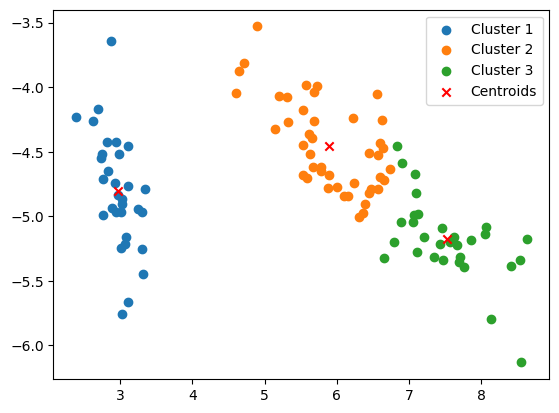

In [102]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from IPython.display import clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 设置随机数种子
np.random.seed(42)

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 定义PCA降维，以便于可视化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# PCA降维
pca = PCA(n_components=2)  # 保留2个主成分（因为平面散点图只有两个坐标轴）
pca = pca.fit(X_scaled)

# 设置K
K = 3

# 设置迭代次数
iters = 20

# 随机选择簇中心
samples = np.random.choice(range(len(X_train)), size=K)
centroids = X_train[samples]

# 初始化每个点的类别
labels = np.zeros(len(X_train))

# K-means聚类
for i in range(iters):
    # 为每个点分配其最近的中心
    for j in range(len(X_train)):
        distances = np.linalg.norm(centroids - X_train[j], axis=1)  # 欧拉距离
        labels[j] = np.argmin(distances, axis=0)                    # 更新类别
    # 更新每个簇中心
    for k in range(K):
        centroids[k] = X_train[labels == k].mean(axis=0)
        
    # 可视化聚类中心
    clear_output(wait=True)  # 清除之前的输出
    for k in range(K):
        cluster_points = X_train[labels == k]
        # PCA降维，便于可视化到平面坐标上
        cluster_points = pca.transform(cluster_points)
        centroids_points = pca.transform(centroids)
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {k+1}')
    plt.scatter(centroids_points[:, 0], centroids_points[:, 1], c='red', marker='x', label='Centroids')    # 绘制质心
    plt.legend()
    plt.show()
    time.sleep(0.5)

c:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


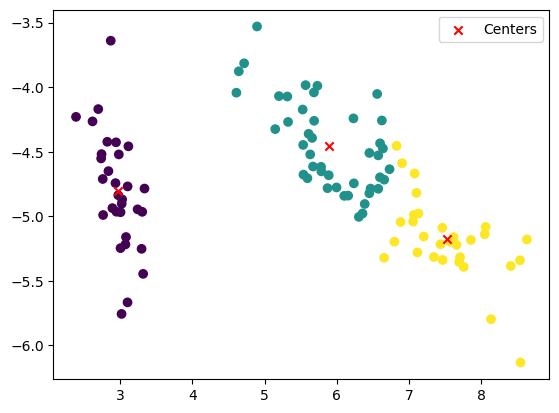

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 设置随机数种子
np.random.seed(42)

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 定义PCA降维，以便于可视化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# PCA降维
pca = PCA(n_components=2)  # 保留2个主成分（因为平面散点图只有两个坐标轴）
pca = pca.fit(X_scaled)

# 创建 KMeans 对象，设定簇的数量为 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
'''
n_clusters: 聚类簇数(默认8)，必须为正整数
init: 初始化方法(默认"k-means++")，可选"random"、数组或可调用对象
n_init: 初始化运行次数(默认"warn")，"auto"时根据init自动选择
max_iter: 最大迭代次数(默认300)
tol: 收敛阈值(默认0.0001)，质心相对变化小于此值停止
verbose: 日志详细程度(默认0)，0不输出，1打印进度
random_state: 随机种子(默认None)，保证结果可复现
copy_x: 是否复制输入数据(默认True)，True时不修改原数据
algorithm: 优化算法(默认"lloyd")，可选"elkan"、"auto"、"full"
'''
# 使用 K-means 进行聚类
kmeans.fit(X_train)

# 降维+可视化
cluster_points = pca.transform(X_train)
centroids_points = pca.transform(kmeans.cluster_centers_)

plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(centroids_points[:, 0], centroids_points[:, 1], marker='x', c='red', label='Centers')
plt.legend()
plt.show()

In [103]:
# 测试样例数据
example_train = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [5.0, 3.6, 1.4, 0.2],
    [7.0, 3.2, 4.7, 1.4],
    [6.9, 3.1, 4.9, 1.5],
    [5.7, 2.5, 5.0, 2.0],
    [5.8, 2.8, 5.1, 2.4]
])

example_test = np.array([[4.8, 3.0, 1.1, 0.1]])

# 样例的训练集类别
for i, et in enumerate(kmeans.transform(example_train)):
    print(f'训练样例 {example_train[i]} 的类别:', np.argmin(et, axis=0))

distance = kmeans.transform(example_test)
print(f'\n测试样例 {example_test[0]} 的类别:', np.argmin(distance[0], axis=0))

训练样例 [5.1 3.5 1.4 0.2] 的类别: 0
训练样例 [5.  3.6 1.4 0.2] 的类别: 0
训练样例 [7.  3.2 4.7 1.4] 的类别: 2
训练样例 [6.9 3.1 4.9 1.5] 的类别: 2
训练样例 [5.7 2.5 5.  2. ] 的类别: 1
训练样例 [5.8 2.8 5.1 2.4] 的类别: 2

测试样例 [4.8 3.  1.1 0.1] 的类别: 0


#### 算法评估指标
###### 簇内平方误差和（SSE）
*衡量每个数据点与其所属簇中心的距离之和。*

$$SSE = \sum\limits_{i=1}^{k} \sum\limits_{x \in C_i} ||x - \mu_i||^2$$

其中：
- $k$ 是簇的数量；

  $C_i$ 是第 $i$ 个簇；

- $x$ 是属于 $C_i$ 的数据点；

- $\mu_i$ 是 $C_i$ 的簇中心。

> SSE 越小，表示**簇内的点越接近簇中心，聚类效果越好**。然而，SSE 随着 K 值的增加通常会减小。因此，不能单独依赖 SSE 来确定最佳的 K 值。

* **在sklearn中，inertia 即 SSE 值**
```python
print("SSE 值 (Inertia):", kmeans.inertia_)
```

##### 轮廓系数（Silhouette Score）
*衡量每个数据点在其簇内的紧密度与它与其他簇的分离度之间的关系*。

$$S = {1\over n}\sum\limits_{i=1}^n \frac{b_i - a_i}{\max(a_i,\ b_i)}$$

其中：
- $a$ 是数据点 ${i}$ 与其簇内其他点的平均距离；
- $b$ 是数据点 ${i}$ 与其最近的其他簇内所有点的平均距离。

> 轮廓系数的取值范围在 -1 到 1 之间：
>
> * 值接近 1 表示聚类效果很好，数据点非常紧密地聚在一起且远离其他簇。
> * 值接近 0 表示数据点在边界上，聚类效果一般。
> * 值为负表示数据点被分配到了错误的簇。

```python
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X, kmeans.labels_)
print("平均轮廓系数 (Silhouette Score):", silhouette_avg)
```

##### **CH 指数（Calinski-Harabasz Index）**
*根据簇内和簇间的方差比率来衡量聚类效果*。

$CH = \frac{Tr(B_k)}{Tr(W_k)} \cdot \frac{n - k}{k - 1}$

其中：
- $Tr(B_k)$ 是簇间的协方差矩阵的迹；
- $Tr(W_k)$ 是簇内的协方差矩阵的迹；
- $n$ 是数据点总数；
- $k$ 是簇的数量。

> CH 指数越大，表示聚类效果越好，簇内点聚得越紧凑，簇间差异越明显。

```python
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X, kmeans.labels_)
print("Calinski-Harabasz 指数:", ch_score)
```



#### K-means的缺点

- 必须事先指定簇的数量 K，依赖人工经验。
- 对初始簇中心的选择敏感，不同的初始值可能会导致不同的聚类结果。
- 只适用于线性可分的数据，复杂的非线性分布可能无法有效划分。